## Tutorial-2: Using multiple datasets

We extend the previous example to a case where we want to analyze the score of a classifier with three different MI datasets instead of just one. As before, we begin by importing all relevant libraries.

In [1]:
import warnings

import matplotlib.pyplot as plt
import mne
import seaborn as sns
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline

import moabb
from moabb.datasets import BNCI2014_001, Zhou2016
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import LeftRightImagery


moabb.set_log_level("info")
mne.set_log_level("CRITICAL")
warnings.filterwarnings("ignore")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initializing Datasets

We instantiate the two different datasets that follow the MI paradigm (with left-hand/right-hand classes) but were recorded with different number of electrodes, different number of trials, etc.



In [2]:
datasets = [Zhou2016(), BNCI2014_001()]
subj = [1,2,3]
for d in datasets:
    d.subject_list = subj
    

The following lines go exactly as in the previous example, where we end up obtaining a pandas dataframe containing the results of the evaluation. We could set overwrite to False to cache the results, avoiding to restart all the evaluation from scratch if a problem occurs.

In [3]:
paradigm = LeftRightImagery()
evaluation = WithinSessionEvaluation(
    paradigm=paradigm, datasets=datasets, overwrite=False
)
pipeline = make_pipeline(CSP(n_components=8), LDA())
results = evaluation.process({"csp_lda": pipeline})

2026-07-15 15:13:21,962 INFO MainThread moabb.datasets.Zhou2016 Creating dataset path: /Users/sheehanmathur/mne_data/MNE-BIDS-zhou2016
SHA256 hash of downloaded file: 4b8aeb7120262dc2ff8cb93d218fdcc09062a65f0ec300afa2e67bb6c81d95dc
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
2026-07-15 15:13:34,454 INFO MainThread moabb.datasets.Zhou2016 Downloading sub-1.zip for subject 1 to /Users/sheehanmathur/mne_data/MNE-BIDS-zhou2016/sub-1.zip
SHA256 hash of downloaded file: 7fa527006f99456fc9789f1611b695e27786bf7b4d383749570cbd5b3310f5fe
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
2026-07-15 15:14:03,129 INFO MainThread moabb.datasets.Zhou2016 Extracting sub-1.zip to /Users/sheehanmathur/mne_data/MNE-BIDS-zhou2016/sub-1
SHA256 hash of downloaded file: e0b5231ca06b97a1597194ee398df2347842e64f45398e62

## Plotting Results

We plot the results using the seaborn library. Note how easy it is to plot the results from the three datasets with just one line.

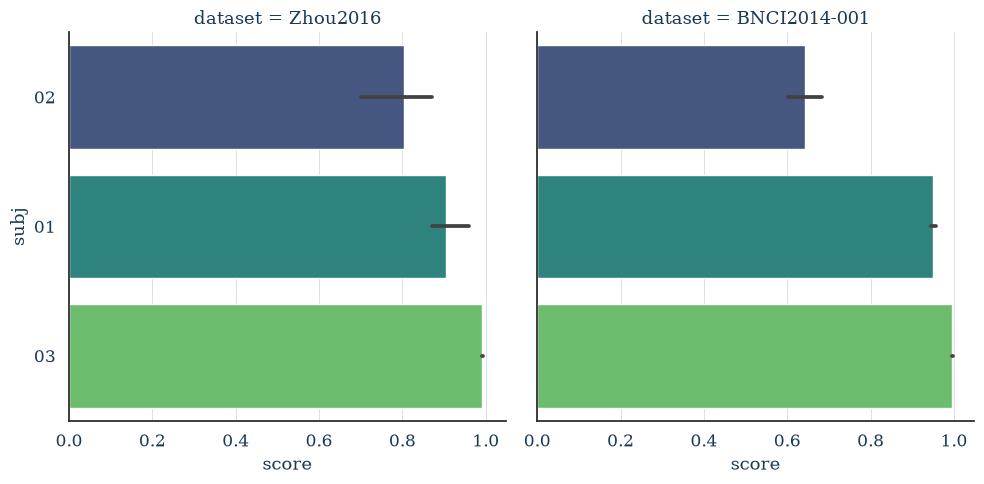

In [4]:
results["subj"] = [str(resi).zfill(2) for resi in results["subject"]]
g = sns.catplot(
    kind="bar",
    x="score", y="subj", col="dataset", data=results, 
    orient="h", palette="viridis",
)
plt.show()